# Cluster-Aware RF, Ensemble, and GB Models

Two clustering schemes from `Clustering.ipynb` are recreated here:
- **xmiss**: KMeans(k=2) on `XMISS_SUMMED`
- **spar and chl**: KMeans(k=2) on `SPAR` + `ESTCHL_SUMMED`

For each clustering, the cluster label is added as a feature and three models are trained:
1. Random Forest (RF)
2. Extra Trees (Ensemble)
3. Histogram Gradient Boosting (GB)

**Total: 6 models**

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import joblib

In [2]:
# ============================================================================
# LOAD DATA
# ============================================================================

CACHE_DIR = Path('../Data/Parquet')
CACHE_DIR.mkdir(exist_ok=True)

def load_or_cache(csv_path, parquet_path, usecols=None):
    parquet_path = Path(parquet_path)
    if parquet_path.exists():
        print(f"Loading cached: {parquet_path}")
        return pd.read_parquet(parquet_path)
    print(f"Reading CSV: {csv_path}")
    df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
    obj_cols = df.select_dtypes(include="object").columns
    if len(obj_cols) > 0:
        df[obj_cols] = df[obj_cols].astype("string")
    print(f"Caching → {parquet_path}")
    df.to_parquet(parquet_path)
    return df

enhanced_df = load_or_cache(
    '../Data/Enhanced.csv',
    CACHE_DIR / 'New_estchlsummed.parquet'
)

# Convert all columns to numeric
for col in enhanced_df.columns:
    enhanced_df[col] = pd.to_numeric(enhanced_df[col], errors='coerce')

print(f"Dataset shape: {enhanced_df.shape}")

Loading cached: ../Data/Parquet/New_estchlsummed.parquet
Dataset shape: (1971, 43)


## Step 1: Recreate Clusterings from Clustering.ipynb

Replicate the two feature sets that yielded the strongest clusters.

In [3]:
# ============================================================================
# CLUSTERING CONFIGURATION
# ============================================================================

N_CLUSTERS = 2
RANDOM_STATE = 42

CLUSTERING_SCHEMES = {
    'xmiss': {
        'features': ['XMISS_SUMMED'],
        'label_col': 'CLUSTER_XMISS'
    },
    'spar_and_chl': {
        'features': ['SPAR', 'ESTCHL_SUMMED'],
        'label_col': 'CLUSTER_SPARC'
    }
}

results_dir = Path('../results')
results_dir.mkdir(exist_ok=True)

models_dir = Path('../Models')
models_dir.mkdir(exist_ok=True)

# Work on a copy that we'll add cluster labels to
df = enhanced_df.copy()
df = df[df['Lat_Dec'].notna() & df['Lon_Dec'].notna() & df['Secchi'].notna()].copy()
print(f"Observations with valid coordinates + Secchi: {len(df)}")

# ============================================================================
# RUN BOTH CLUSTERINGS
# ============================================================================

cluster_scalers = {}
cluster_models = {}

print("\n" + "="*80)
print("RUNNING CLUSTERINGS")
print("="*80)

for scheme_name, config in CLUSTERING_SCHEMES.items():
    features = config['features']
    label_col = config['label_col']

    print(f"\n--- {scheme_name} | features: {features} ---")

    # Subset rows where clustering features are available
    X_clust = df[features].dropna()
    print(f"  Rows with complete clustering features: {len(X_clust)}")

    # Standardize (important for KMeans)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clust)

    # KMeans clustering
    km = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)

    cluster_scalers[scheme_name] = scaler
    cluster_models[scheme_name] = km

    # Assign labels back (NaN for rows without the clustering features)
    df[label_col] = np.nan
    df.loc[X_clust.index, label_col] = labels

    sizes = pd.Series(labels).value_counts().sort_index()
    for c, n in sizes.items():
        print(f"  Cluster {c}: {n} observations ({n/len(X_clust)*100:.1f}%)")

print("\nCluster labels added to dataset.")
print(df[[c['label_col'] for c in CLUSTERING_SCHEMES.values()]].describe())

Observations with valid coordinates + Secchi: 1971

RUNNING CLUSTERINGS

--- xmiss | features: ['XMISS_SUMMED'] ---
  Rows with complete clustering features: 1971
  Cluster 0: 1534 observations (77.8%)
  Cluster 1: 437 observations (22.2%)

--- spar_and_chl | features: ['SPAR', 'ESTCHL_SUMMED'] ---
  Rows with complete clustering features: 1793
  Cluster 0: 1677 observations (93.5%)
  Cluster 1: 116 observations (6.5%)

Cluster labels added to dataset.
       CLUSTER_XMISS  CLUSTER_SPARC
count    1971.000000    1793.000000
mean        0.221715       0.064696
std         0.415506       0.246057
min         0.000000       0.000000
25%         0.000000       0.000000
50%         0.000000       0.000000
75%         0.000000       0.000000
max         1.000000       1.000000


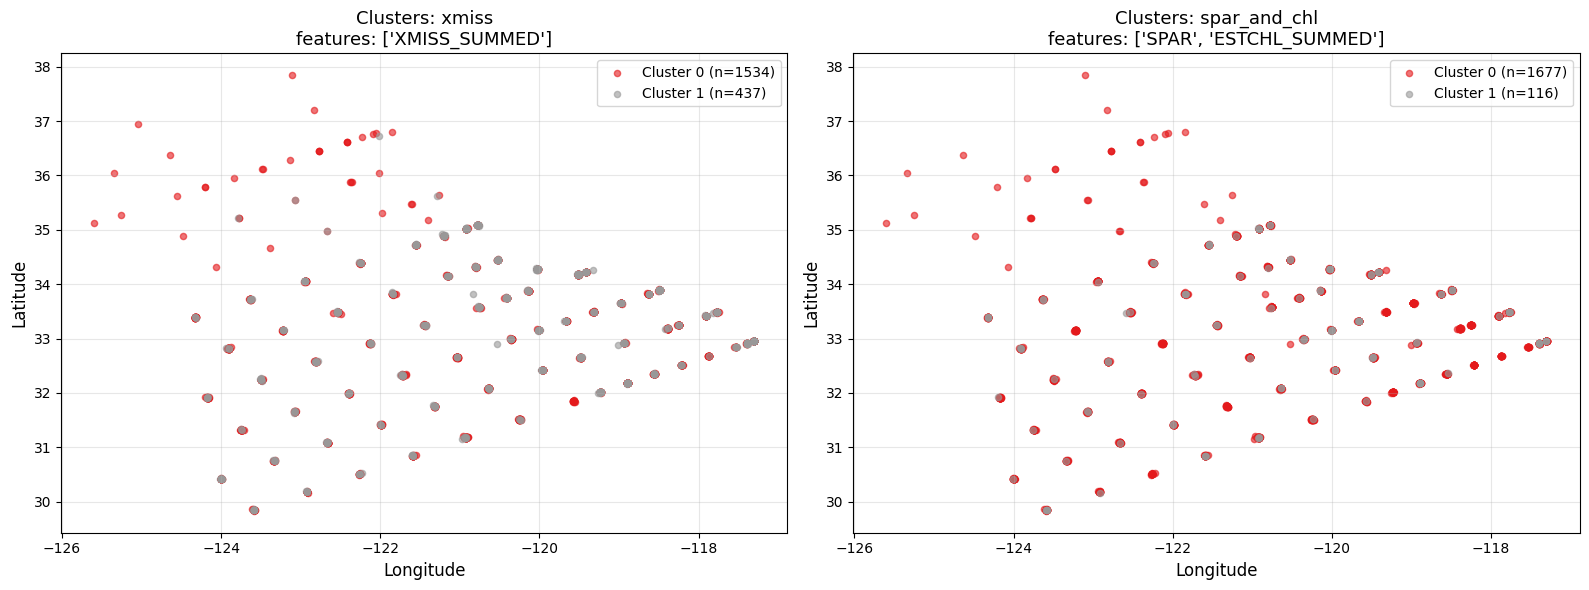

Saved: ../results/clustered_models_cluster_geography.png


In [4]:
# ============================================================================
# VISUALIZE CLUSTERS
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.Set1(np.linspace(0, 1, N_CLUSTERS))

for ax, (scheme_name, config) in zip(axes, CLUSTERING_SCHEMES.items()):
    label_col = config['label_col']
    df_valid = df[df[label_col].notna()].copy()
    df_valid[label_col] = df_valid[label_col].astype(int)

    for i in range(N_CLUSTERS):
        subset = df_valid[df_valid[label_col] == i]
        ax.scatter(subset['Lon_Dec'], subset['Lat_Dec'],
                   c=[colors[i]], label=f'Cluster {i} (n={len(subset)})',
                   alpha=0.6, s=20)

    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title(f'Clusters: {scheme_name}\nfeatures: {config["features"]}', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'clustered_models_cluster_geography.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {results_dir / 'clustered_models_cluster_geography.png'}")

## Step 2: Define Feature Set and Model Training Function

In [5]:
# ============================================================================
# FEATURE / TARGET CONFIGURATION
# ============================================================================

TARGET_COL = 'Secchi'

EXCLUDE_COLS = [
    'ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
    'LON_DEC', 'STA_ID', 'PRESSURE',
    'ESTCHL_CRUISECORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
    'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE',
    'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID',
    'Distance', 'Date', 'Time', 'Ac_Line', 'Bottom_D',
    'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'CHL_A_SUMMED'
]

# Base features (no cluster labels yet)
BASE_FEATURE_COLS = [
    col for col in df.columns
    if col not in EXCLUDE_COLS + [TARGET_COL]
    and col not in [c['label_col'] for c in CLUSTERING_SCHEMES.values()]
]

print(f"Base features ({len(BASE_FEATURE_COLS)}): {BASE_FEATURE_COLS}")

Base features (11): ['LINE', 'STA', 'DEPTH', 'ESTCHL_STACORR', 'XMISS_SUMMED', 'PHAEO_SUMMED', 'ESTCHL_SUMMED', 'Lat_Dec', 'Lon_Dec', 'K_PAR', 'K_PAR_SLOPE']


In [6]:
# ============================================================================
# TRAINING FUNCTION
# ============================================================================

def train_and_evaluate_model(data, feature_cols, target_col, model_name, model_type='rf'):
    """
    Train and evaluate a model with median imputation, 5-fold CV, and test metrics.
    model_type: 'rf' | 'ensemble' (ExtraTrees) | 'gb' (HistGradientBoosting)
    Returns a result dict with model, metrics, predictions, and feature importances.
    """
    print(f"\n{'='*80}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*80}")

    X = data[feature_cols].copy()
    y = data[target_col].copy()

    # Keep only rows with valid target
    mask = y.notna() & (y > 0)
    X, y = X[mask], y[mask]
    print(f"Sample size (valid target): {len(X)}")

    # Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

    # Median imputation
    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index
    )
    X_test_imp = pd.DataFrame(
        imputer.transform(X_test), columns=X_test.columns, index=X_test.index
    )

    # Build model
    if model_type == 'rf':
        model = RandomForestRegressor(
            n_estimators=200, max_depth=15,
            min_samples_split=5, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        )
    elif model_type == 'ensemble':  # Extra Trees
        model = ExtraTreesRegressor(
            n_estimators=200, max_depth=15,
            min_samples_split=5, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        )
    else:  # 'gb' — HistGradientBoosting handles NaNs natively
        model = HistGradientBoostingRegressor(
            max_iter=300, max_depth=10,
            learning_rate=0.05, min_samples_leaf=20,
            random_state=42
        )

    # 5-fold CV on training data
    print("Performing 5-Fold CV...")
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    # HistGB handles NaNs natively, so for GB pass raw X_train (with NaNs)
    cv_X = X_train if model_type == 'gb' else X_train_imp
    cv_rmse = np.sqrt(-cross_val_score(model, cv_X, y_train, cv=kfold,
                                       scoring='neg_mean_squared_error'))
    cv_r2 = cross_val_score(model, cv_X, y_train, cv=kfold, scoring='r2')

    print(f"CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
    print(f"CV R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

    # Final fit
    fit_X_train = X_train if model_type == 'gb' else X_train_imp
    fit_X_test  = X_test  if model_type == 'gb' else X_test_imp
    model.fit(fit_X_train, y_train)

    y_train_pred = model.predict(fit_X_train)
    y_test_pred  = model.predict(fit_X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2   = r2_score(y_train, y_train_pred)
    test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2    = r2_score(y_test, y_test_pred)
    test_mae   = mean_absolute_error(y_test, y_test_pred)

    print(f"Train — RMSE: {train_rmse:.4f}  R²: {train_r2:.4f}")
    print(f"Test  — RMSE: {test_rmse:.4f}  MAE: {test_mae:.4f}  R²: {test_r2:.4f}")

    # Feature importances (not available for HistGB via .feature_importances_)
    if hasattr(model, 'feature_importances_'):
        feat_imp = pd.DataFrame({
            'feature': feature_cols,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        print(f"\nTop 10 features:")
        print(feat_imp.head(10).to_string(index=False))
    else:
        feat_imp = None

    # Save model + imputer
    joblib.dump(model,   models_dir / f"{model_name}.joblib")
    joblib.dump(imputer, models_dir / f"{model_name}_imputer.joblib")
    if feat_imp is not None:
        feat_imp.to_csv(models_dir / f"{model_name}_importance.csv", index=False)
    print(f"Saved: {models_dir / model_name}.joblib")

    return {
        'model': model,
        'imputer': imputer,
        'cv_rmse': cv_rmse,
        'cv_r2': cv_r2,
        'train_rmse': train_rmse, 'train_r2': train_r2,
        'test_rmse': test_rmse, 'test_r2': test_r2, 'test_mae': test_mae,
        'y_test': y_test, 'y_test_pred': y_test_pred,
        'feature_importance': feat_imp,
        'feature_cols': feature_cols
    }

## Step 3a: Models Using `xmiss` Clustering

Cluster label `CLUSTER_XMISS` is added as an additional predictor feature.

In [7]:
# ============================================================================
# xmiss CLUSTERING — RF, Ensemble, GB
# ============================================================================

xmiss_label = CLUSTERING_SCHEMES['xmiss']['label_col']

# Features: base features + xmiss cluster label
xmiss_feature_cols = BASE_FEATURE_COLS + [xmiss_label]

# Use only rows where the cluster label is assigned
df_xmiss = df[df[xmiss_label].notna()].copy()
print(f"Dataset for xmiss-clustered models: {len(df_xmiss)} rows")
print(f"Features ({len(xmiss_feature_cols)}): {xmiss_feature_cols}")

xmiss_results = {}

xmiss_results['rf'] = train_and_evaluate_model(
    df_xmiss, xmiss_feature_cols, TARGET_COL,
    model_name='xmiss_cluster_random_forest', model_type='rf'
)

xmiss_results['ensemble'] = train_and_evaluate_model(
    df_xmiss, xmiss_feature_cols, TARGET_COL,
    model_name='xmiss_cluster_extra_trees', model_type='ensemble'
)

xmiss_results['gb'] = train_and_evaluate_model(
    df_xmiss, xmiss_feature_cols, TARGET_COL,
    model_name='xmiss_cluster_gradient_boosting', model_type='gb'
)

Dataset for xmiss-clustered models: 1971 rows
Features (12): ['LINE', 'STA', 'DEPTH', 'ESTCHL_STACORR', 'XMISS_SUMMED', 'PHAEO_SUMMED', 'ESTCHL_SUMMED', 'Lat_Dec', 'Lon_Dec', 'K_PAR', 'K_PAR_SLOPE', 'CLUSTER_XMISS']

TRAINING: xmiss_cluster_random_forest
Sample size (valid target): 1971
Train: 1576  |  Test: 395
Performing 5-Fold CV...
CV RMSE: 4.2286 ± 0.2898
CV R²:   0.7647 ± 0.0201
Train — RMSE: 1.9921  R²: 0.9480
Test  — RMSE: 4.4432  MAE: 3.3136  R²: 0.7456

Top 10 features:
       feature  importance
 ESTCHL_SUMMED    0.737211
   K_PAR_SLOPE    0.063236
ESTCHL_STACORR    0.042562
         K_PAR    0.035535
  XMISS_SUMMED    0.034807
  PHAEO_SUMMED    0.019978
       Lat_Dec    0.019735
       Lon_Dec    0.019657
         DEPTH    0.013039
           STA    0.009003
Saved: ../Models/xmiss_cluster_random_forest.joblib

TRAINING: xmiss_cluster_extra_trees
Sample size (valid target): 1971
Train: 1576  |  Test: 395
Performing 5-Fold CV...
CV RMSE: 4.2616 ± 0.2645
CV R²:   0.7610 ± 0.0

## Step 3b: Models Using `spar and chl` Clustering

Cluster label `CLUSTER_SPARC` is added as an additional predictor feature.

In [8]:
# ============================================================================
# spar_and_chl CLUSTERING — RF, Ensemble, GB
# ============================================================================

sparc_label = CLUSTERING_SCHEMES['spar_and_chl']['label_col']

# Features: base features + sparc cluster label
sparc_feature_cols = BASE_FEATURE_COLS + [sparc_label]

# Use only rows where the cluster label is assigned
df_sparc = df[df[sparc_label].notna()].copy()
print(f"Dataset for spar+chl-clustered models: {len(df_sparc)} rows")
print(f"Features ({len(sparc_feature_cols)}): {sparc_feature_cols}")

sparc_results = {}

sparc_results['rf'] = train_and_evaluate_model(
    df_sparc, sparc_feature_cols, TARGET_COL,
    model_name='sparc_cluster_random_forest', model_type='rf'
)

sparc_results['ensemble'] = train_and_evaluate_model(
    df_sparc, sparc_feature_cols, TARGET_COL,
    model_name='sparc_cluster_extra_trees', model_type='ensemble'
)

sparc_results['gb'] = train_and_evaluate_model(
    df_sparc, sparc_feature_cols, TARGET_COL,
    model_name='sparc_cluster_gradient_boosting', model_type='gb'
)

Dataset for spar+chl-clustered models: 1793 rows
Features (12): ['LINE', 'STA', 'DEPTH', 'ESTCHL_STACORR', 'XMISS_SUMMED', 'PHAEO_SUMMED', 'ESTCHL_SUMMED', 'Lat_Dec', 'Lon_Dec', 'K_PAR', 'K_PAR_SLOPE', 'CLUSTER_SPARC']

TRAINING: sparc_cluster_random_forest
Sample size (valid target): 1793
Train: 1434  |  Test: 359
Performing 5-Fold CV...
CV RMSE: 4.3010 ± 0.1930
CV R²:   0.7554 ± 0.0154
Train — RMSE: 2.0372  R²: 0.9454
Test  — RMSE: 4.0659  MAE: 2.9724  R²: 0.7825

Top 10 features:
       feature  importance
 ESTCHL_SUMMED    0.741522
   K_PAR_SLOPE    0.059820
  XMISS_SUMMED    0.036937
ESTCHL_STACORR    0.036311
         K_PAR    0.026517
       Lat_Dec    0.022830
       Lon_Dec    0.021762
  PHAEO_SUMMED    0.019935
         DEPTH    0.018414
           STA    0.008531
Saved: ../Models/sparc_cluster_random_forest.joblib

TRAINING: sparc_cluster_extra_trees
Sample size (valid target): 1793
Train: 1434  |  Test: 359
Performing 5-Fold CV...
CV RMSE: 4.3030 ± 0.2147
CV R²:   0.7551 ± 

## Step 4: Comparison Summary

In [9]:
# ============================================================================
# COMPARISON SUMMARY
# ============================================================================

all_results = {
    'xmiss_RF':       xmiss_results['rf'],
    'xmiss_Ensemble': xmiss_results['ensemble'],
    'xmiss_GB':       xmiss_results['gb'],
    'sparc_RF':       sparc_results['rf'],
    'sparc_Ensemble': sparc_results['ensemble'],
    'sparc_GB':       sparc_results['gb'],
}

summary_rows = []
for name, res in all_results.items():
    summary_rows.append({
        'Model': name,
        'CV_R2_mean':  res['cv_r2'].mean(),
        'CV_RMSE_mean': res['cv_rmse'].mean(),
        'Test_R2':   res['test_r2'],
        'Test_RMSE': res['test_rmse'],
        'Test_MAE':  res['test_mae'],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Test_R2', ascending=False)

print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY (sorted by Test R²)")
print("="*80)
print(summary_df.to_string(index=False))

summary_df.to_csv(results_dir / 'clustered_models_summary.csv', index=False)
print(f"\nSaved: {results_dir / 'clustered_models_summary.csv'}")


MODEL COMPARISON SUMMARY (sorted by Test R²)
         Model  CV_R2_mean  CV_RMSE_mean  Test_R2  Test_RMSE  Test_MAE
      sparc_RF    0.755439      4.301049 0.782493   4.065917  2.972399
      sparc_GB    0.742164      4.416591 0.775013   4.135236  3.006108
sparc_Ensemble    0.755096      4.302974 0.762694   4.246940  3.120221
      xmiss_GB    0.749263      4.366374 0.747960   4.422113  3.283127
      xmiss_RF    0.764677      4.228614 0.745550   4.443201  3.313605
xmiss_Ensemble    0.760991      4.261632 0.742246   4.471956  3.343312

Saved: ../results/clustered_models_summary.csv


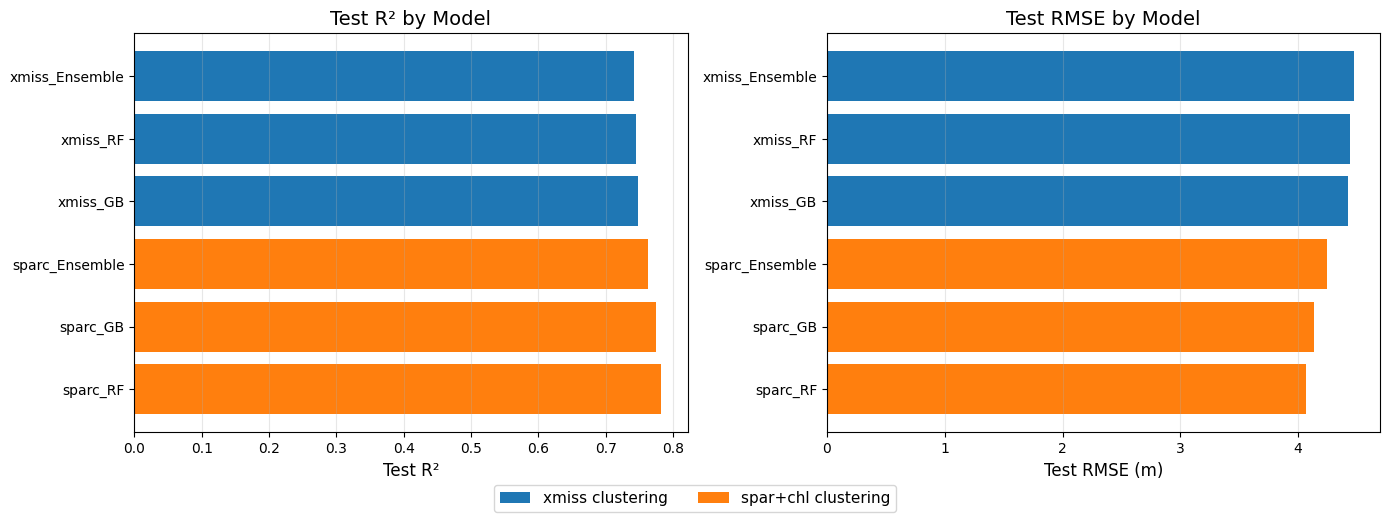

Saved: ../results/clustered_models_performance_comparison.png


In [10]:
# ============================================================================
# PLOT 1: PERFORMANCE BAR CHART
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_ordered = summary_df['Model'].tolist()
y_pos = range(len(models_ordered))

# R²
colors_bar = ['#1f77b4' if 'xmiss' in m else '#ff7f0e' for m in models_ordered]
axes[0].barh(y_pos, summary_df['Test_R2'], color=colors_bar)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(models_ordered)
axes[0].set_xlabel('Test R²', fontsize=12)
axes[0].set_title('Test R² by Model', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='x')

# RMSE
axes[1].barh(y_pos, summary_df['Test_RMSE'], color=colors_bar)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(models_ordered)
axes[1].set_xlabel('Test RMSE (m)', fontsize=12)
axes[1].set_title('Test RMSE by Model', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='x')

# Legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='xmiss clustering'),
                   Patch(facecolor='#ff7f0e', label='spar+chl clustering')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig(results_dir / 'clustered_models_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {results_dir / 'clustered_models_performance_comparison.png'}")

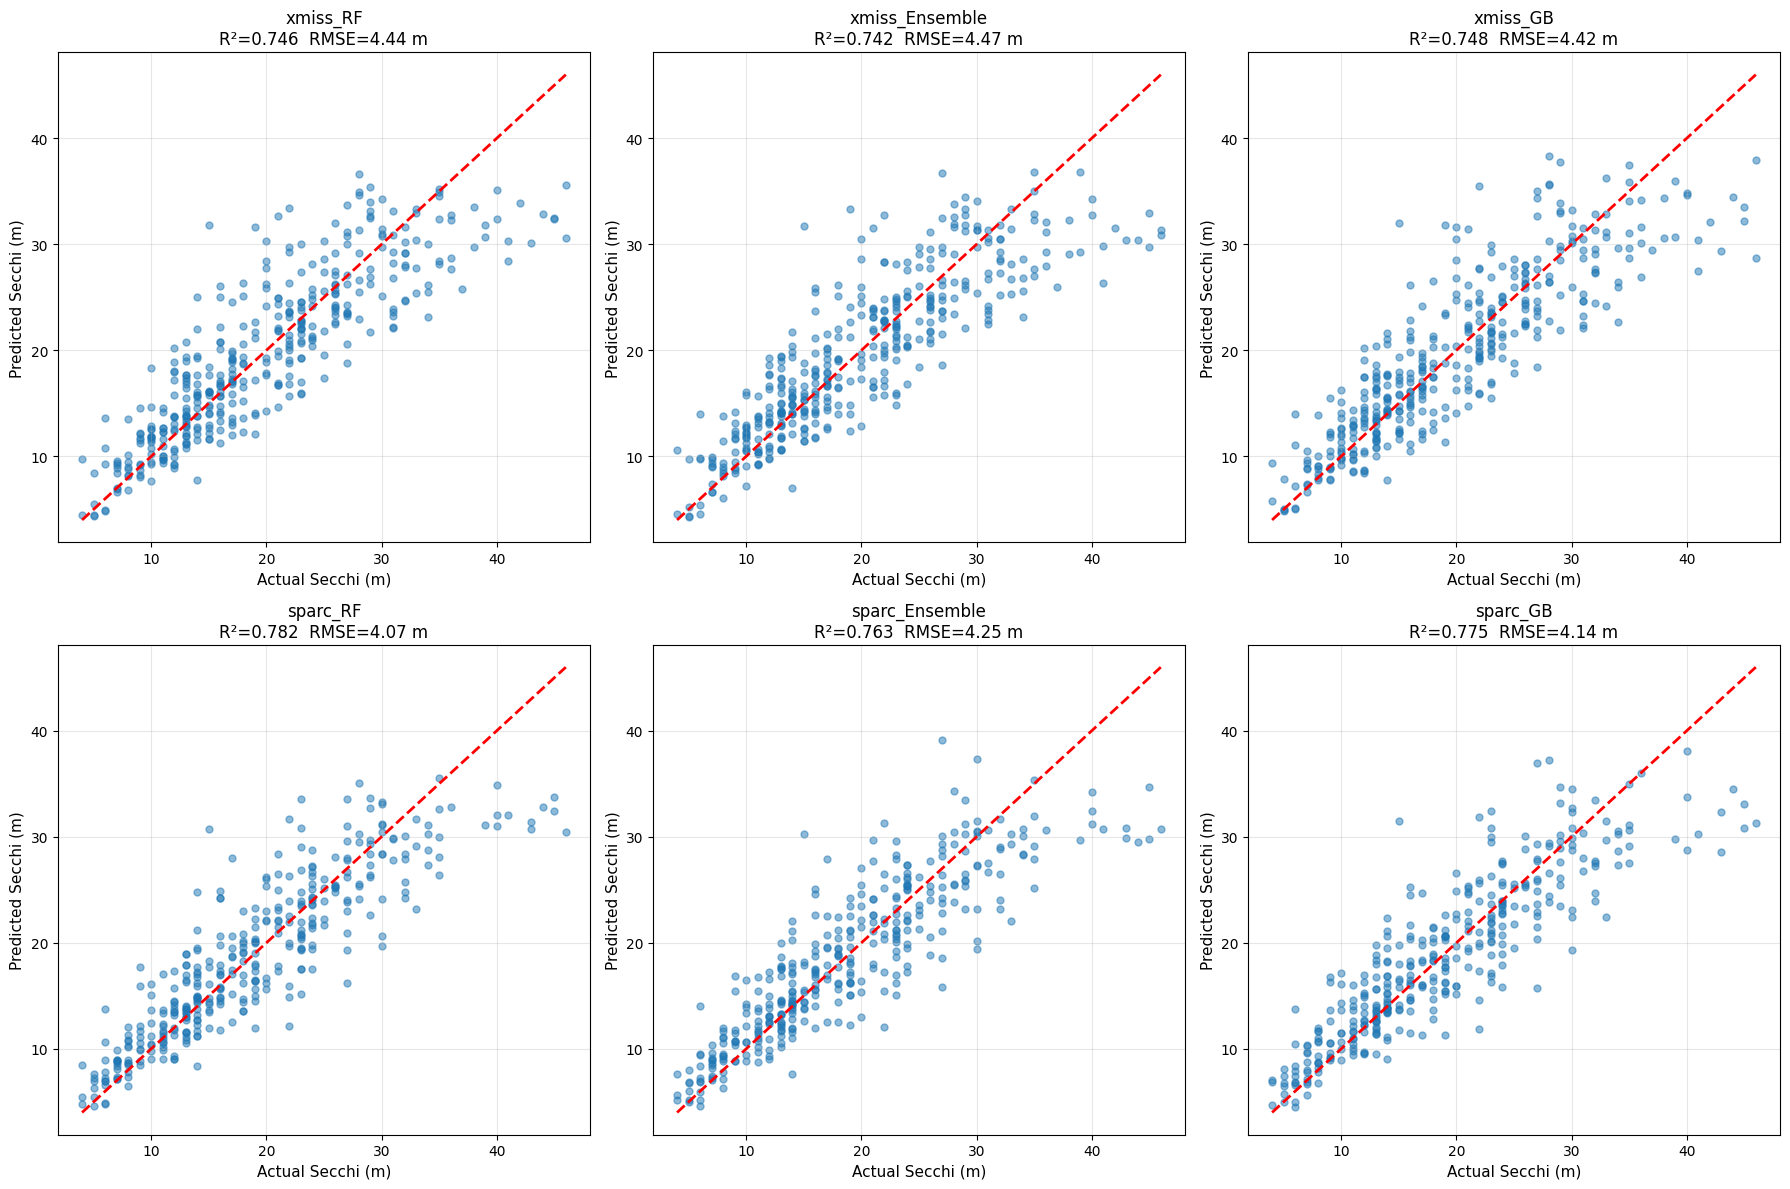

Saved: ../results/clustered_models_actual_vs_predicted.png


In [11]:
# ============================================================================
# PLOT 2: ACTUAL vs PREDICTED — all 6 models
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (model_name, res) in enumerate(all_results.items()):
    y_true = res['y_test']
    y_pred = res['y_test_pred']

    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    axes[idx].scatter(y_true, y_pred, alpha=0.5, s=25)
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    axes[idx].plot([lo, hi], [lo, hi], 'r--', lw=2)
    axes[idx].set_xlabel('Actual Secchi (m)', fontsize=11)
    axes[idx].set_ylabel('Predicted Secchi (m)', fontsize=11)
    axes[idx].set_title(f'{model_name}\nR²={r2:.3f}  RMSE={rmse:.2f} m', fontsize=12)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'clustered_models_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {results_dir / 'clustered_models_actual_vs_predicted.png'}")

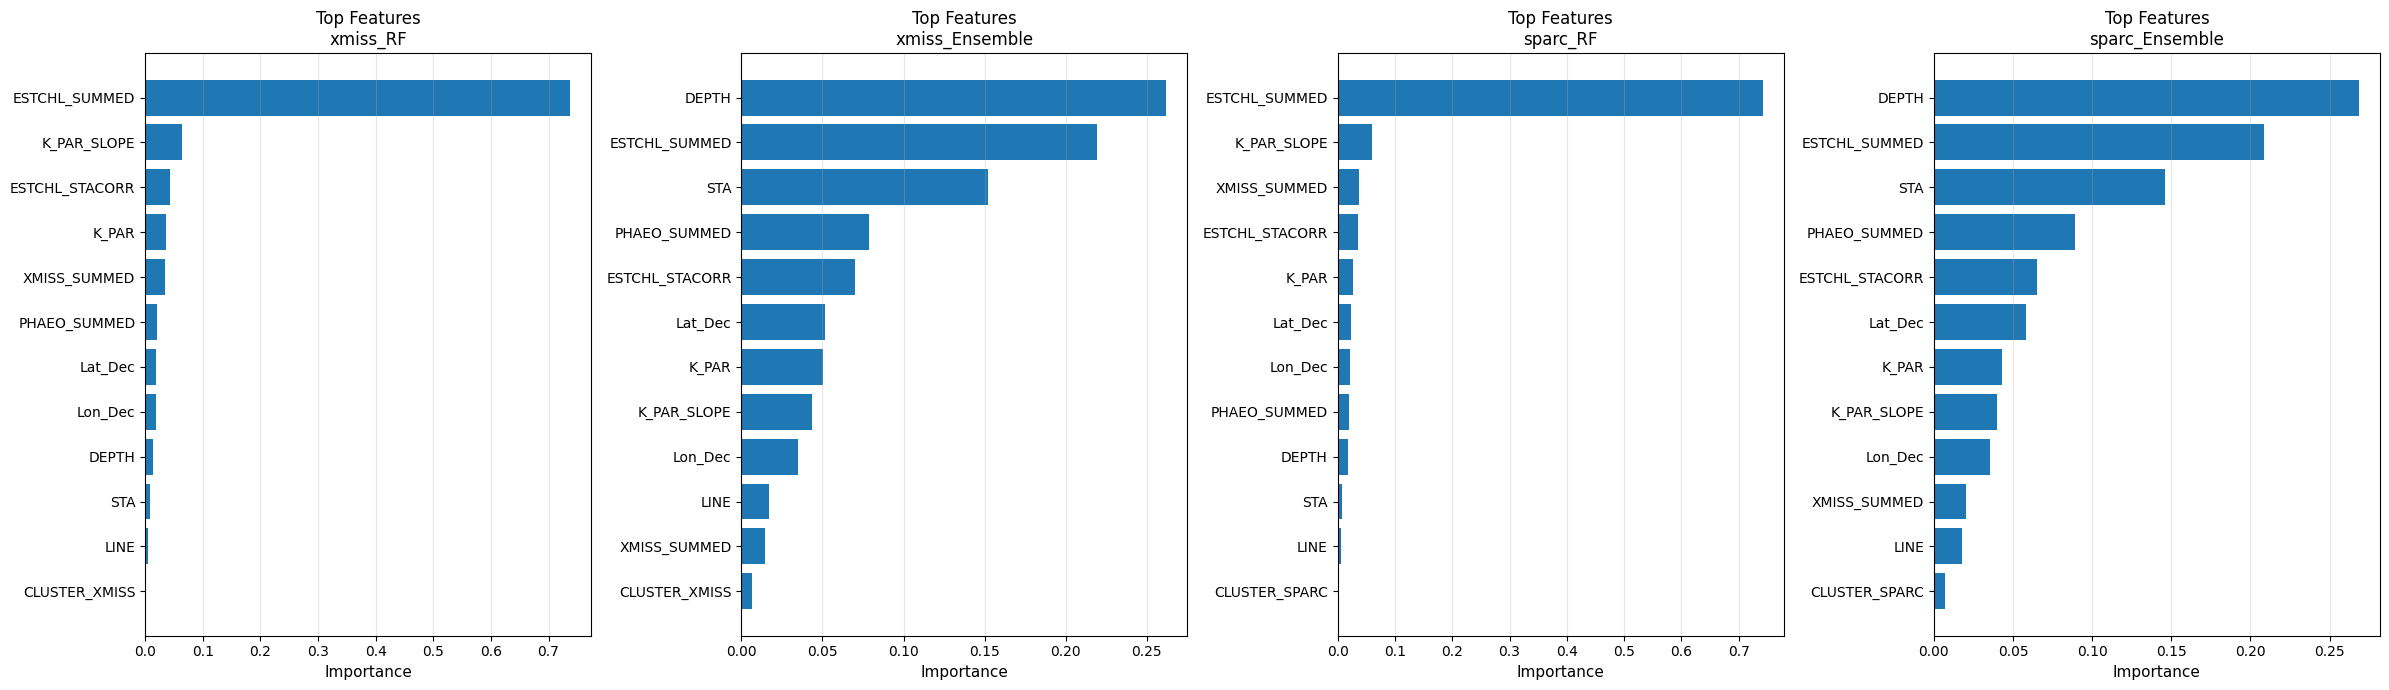

Saved: ../results/clustered_models_feature_importance.png


In [12]:
# ============================================================================
# PLOT 3: FEATURE IMPORTANCE — RF and Ensemble models (have .feature_importances_)
# ============================================================================

importance_models = {
    k: v for k, v in all_results.items()
    if v['feature_importance'] is not None
}

n_imp = len(importance_models)
fig, axes = plt.subplots(1, n_imp, figsize=(6 * n_imp, 7))
if n_imp == 1:
    axes = [axes]

for ax, (model_name, res) in zip(axes, importance_models.items()):
    top = res['feature_importance'].head(12)
    ax.barh(range(len(top)), top['importance'])
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top['feature'], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Importance', fontsize=11)
    ax.set_title(f'Top Features\n{model_name}', fontsize=12)
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(results_dir / 'clustered_models_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {results_dir / 'clustered_models_feature_importance.png'}")

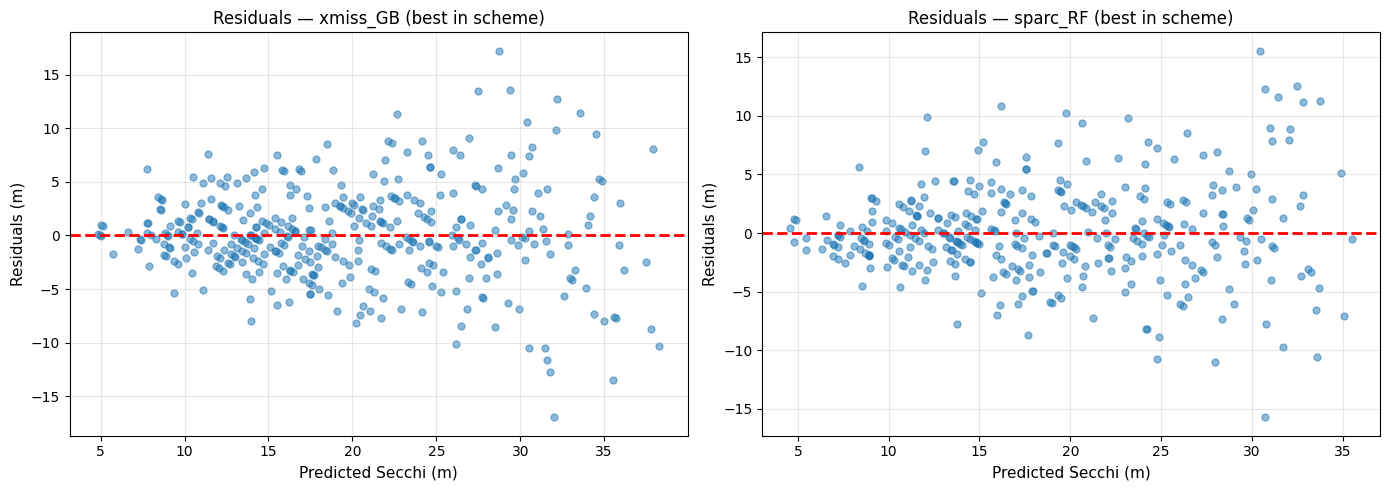

Saved: ../results/clustered_models_residuals.png


In [13]:
# ============================================================================
# PLOT 4: RESIDUALS — best model per clustering scheme
# ============================================================================

# Best model for each scheme
xmiss_best_name = max(
    ['xmiss_RF', 'xmiss_Ensemble', 'xmiss_GB'],
    key=lambda k: all_results[k]['test_r2']
)
sparc_best_name = max(
    ['sparc_RF', 'sparc_Ensemble', 'sparc_GB'],
    key=lambda k: all_results[k]['test_r2']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, best_name in zip(axes, [xmiss_best_name, sparc_best_name]):
    res = all_results[best_name]
    residuals = res['y_test'] - res['y_test_pred']

    ax.scatter(res['y_test_pred'], residuals, alpha=0.5, s=25)
    ax.axhline(0, color='red', linestyle='--', lw=2)
    ax.set_xlabel('Predicted Secchi (m)', fontsize=11)
    ax.set_ylabel('Residuals (m)', fontsize=11)
    ax.set_title(f'Residuals — {best_name} (best in scheme)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'clustered_models_residuals.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {results_dir / 'clustered_models_residuals.png'}")

In [14]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

best_overall = summary_df.iloc[0]

print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"\nBest model overall: {best_overall['Model']}")
print(f"  Test R²:   {best_overall['Test_R2']:.4f}")
print(f"  Test RMSE: {best_overall['Test_RMSE']:.4f} m")
print(f"  Test MAE:  {best_overall['Test_MAE']:.4f} m")

print("\nAll 6 models saved to:", models_dir)
print("Results saved to:", results_dir)

print("\nModel files:")
for model_name in [
    'xmiss_cluster_random_forest', 'xmiss_cluster_extra_trees', 'xmiss_cluster_gradient_boosting',
    'sparc_cluster_random_forest', 'sparc_cluster_extra_trees', 'sparc_cluster_gradient_boosting'
]:
    path = models_dir / f"{model_name}.joblib"
    print(f"  {'✓' if path.exists() else '✗'} {path.name}")


FINAL SUMMARY

Best model overall: sparc_RF
  Test R²:   0.7825
  Test RMSE: 4.0659 m
  Test MAE:  2.9724 m

All 6 models saved to: ../Models
Results saved to: ../results

Model files:
  ✓ xmiss_cluster_random_forest.joblib
  ✓ xmiss_cluster_extra_trees.joblib
  ✓ xmiss_cluster_gradient_boosting.joblib
  ✓ sparc_cluster_random_forest.joblib
  ✓ sparc_cluster_extra_trees.joblib
  ✓ sparc_cluster_gradient_boosting.joblib
